In [1]:
IS_ON_CLOUD = False

# **2110433 - Computer Vision (2024/2)**
#**Lab 9 - Modern Object Detection [Homework]** <br>
In this lab, we will learn how to use MMDetection to perform object detection in the provided real world dataset using PyTorch. This notebook includes both coding and written questions. Please hand in this notebook file with all outputs and your answer.

**Collaboration is encouraged in this course.** You must turn in your own write ups of all problems. If you collaborate with others, you must put the names and ids of the students you worked with in below block.

Collaboration List:
- ...
- ...


# Assignment 1 : Parasite Detection
![alt text](https://icip2022challenge.piclab.ai/wp-content/uploads/2022/01/parasite_egg_11_with_size.png)

In this assignment you have to replace YOUR_STUDENT_ID_WITH21 variable with your student id (in integer). There will be 2 sets of data: train and test

By using the knowledge from the lab and lecture, you have to train object detection model and tested on unknown label dataset!



Scoreboard URL : https://www.piclab.ai/classes/cv2024/lab9/scoreboard

### Hints
- The parasite dataset was created using COCO dataset format
- If you use MMDetection, the dataset is ready to use
- If you want to use Ultralytics, you have to format to YOLO dataset format (use Fiftyone!)


## GPU Status Check

In [2]:
!nvidia-smi

Sat Mar 29 10:30:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Download and inspect parasite dataset

In [3]:
%pip install --upgrade gdown
!gdown "https://drive.google.com/uc?id=1RVluBzZvJ8mWwA5AuB2PklbaoK60uPMF"
!gdown "https://drive.google.com/uc?id=1kvBxmC1o0vE2ef2CJqhLaj9V4TD72oW3"
!unzip parasite_train.zip
!unzip parasite_test.zip

Note: you may need to restart the kernel to use updated packages.
Downloading...
From (original): https://drive.google.com/uc?id=1RVluBzZvJ8mWwA5AuB2PklbaoK60uPMF
From (redirected): https://drive.google.com/uc?id=1RVluBzZvJ8mWwA5AuB2PklbaoK60uPMF&confirm=t&uuid=b685c233-67d8-4036-a113-33dcb9290508
To: /kaggle/working/parasite_test.zip
100%|████████████████████████████████████████| 142M/142M [00:04<00:00, 34.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1kvBxmC1o0vE2ef2CJqhLaj9V4TD72oW3
From (redirected): https://drive.google.com/uc?id=1kvBxmC1o0vE2ef2CJqhLaj9V4TD72oW3&confirm=t&uuid=e9bd36f8-872f-453f-820c-4097065b3921
To: /kaggle/working/parasite_train.zip
100%|████████████████████████████████████████| 715M/715M [00:22<00:00, 32.5MB/s]
Archive:  parasite_train.zip
   creating: parasite_train/
  inflating: parasite_train/labels.json  
   creating: parasite_train/data/
  inflating: parasite_train/data/Hymenolepis nana_0371.jpg  
  inflating: __MACOSX/parasite_tra

## Your model description goes here: ###
WRITE HERE

### Dataset Exploration
We will use pycocotools to explore this dataset.

In [4]:
%pip install -q pycocotools

Note: you may need to restart the kernel to use updated packages.


In [5]:
from pycocotools.coco import COCO
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [6]:
trainLabelFile='/kaggle/working/parasite_train/labels.json'
# initialize COCO api for instance annotations
trainCOCOBinding = COCO(trainLabelFile)

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


COCO categories: 
Capillaria philippinensis, Enterobius vermicularis, Hymenolepis diminuta, Hymenolepis nana, Paragonimus spp

Image Data >> {'id': 109, 'file_name': 'Hymenolepis nana_0541.jpg', 'height': 1080, 'width': 1920, 'license': None, 'coco_url': None}
Box Data [{'id': 109, 'image_id': 109, 'category_id': 3, 'bbox': [868.0, 489.0, 130.0, 119.0], 'area': 15470.0, 'iscrowd': 0}]


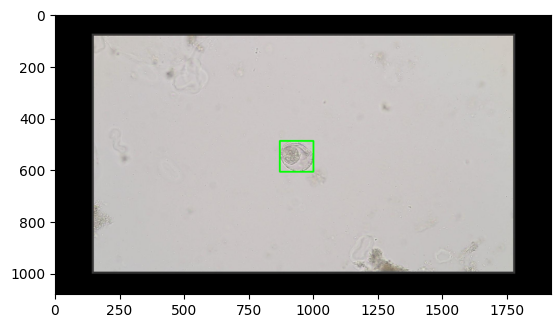

In [7]:
#display COCO categories and supercategories
cats = trainCOCOBinding.loadCats(trainCOCOBinding.getCatIds())
nms=[cat['name'] for cat in cats]
print('COCO categories: \n{}\n'.format(', '.join(nms)))

# get all images containing given categories, select one at random
catIds = trainCOCOBinding.getCatIds(catNms=['Hymenolepis diminuta',]);
imgIds = trainCOCOBinding.getImgIds(catIds=catIds );

randomImgId = np.random.randint(0,len(imgIds))
sampleImageData = trainCOCOBinding.loadImgs(randomImgId)[0]

print('Image Data >>', sampleImageData)

sampleImage = cv2.imread('/kaggle/working/parasite_train/data/'+sampleImageData['file_name'])

annIds = trainCOCOBinding.getAnnIds(imgIds=randomImgId, iscrowd=None)
boxes = trainCOCOBinding.loadAnns(annIds)
print('Box Data', boxes)

for box in boxes:
  x,y,w,h = box['bbox']
  cv2.rectangle(sampleImage, (int(x), int(y)), (int(x+w), int(y+h)), (0,255,0), 5)

sampleImage = cv2.cvtColor(sampleImage, cv2.COLOR_BGR2RGB)

plt.imshow(sampleImage)
plt.show()

### Create YOLO dataset structure

In [14]:
import os
from tqdm import tqdm

# Create a directory to store the YOLO dataset
ROOT_DIR = "datasets/parasite_dataset"
os.makedirs(ROOT_DIR, exist_ok=True)

# Create subdirectories for images and labels
IMAGES_DIR = os.path.join(ROOT_DIR, "images")
LABELS_DIR = os.path.join(ROOT_DIR, "labels")
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(LABELS_DIR, exist_ok=True)

# Create subdirectories for train and validation sets
TRAIN_DIR = (os.path.join(IMAGES_DIR, "train"), os.path.join(LABELS_DIR, "train"))
VAL_DIR = (os.path.join(IMAGES_DIR, "val"), os.path.join(LABELS_DIR, "val"))
for dir_path in TRAIN_DIR + VAL_DIR:
    os.makedirs(dir_path, exist_ok=True)

In [15]:
import random
random.seed(42)

In [16]:
looper = tqdm(trainCOCOBinding.dataset['annotations'])
for annotation in looper:
    image_id, category_id, bbox = annotation['image_id'], annotation['category_id'], annotation['bbox']
    if trainCOCOBinding.dataset['images'][image_id-1]['id'] != image_id:
        print('Image ID mismatch')
        continue
    
    image_info  = trainCOCOBinding.dataset['images'][image_id-1]
    file_name, height, width = image_info['file_name'], image_info['height'], image_info['width']
    file_path = os.path.join('./parasite_train/data', file_name)
    file_name = file_name.replace(' ', '_')
    if not os.path.exists(file_path):
        print('File not found:', file_path)
        continue

    # Normalize the bounding box coordinates
    x_center = bbox[0] / width
    y_center = bbox[1] / height
    bbox_width = bbox[2] / width
    bbox_height = bbox[3] / height

    # Copy data to the YOLO dataset
    # Determine the destination directory (train or val)
    if random.random() < 0.8:
        dest_dir = TRAIN_DIR
    else:
        dest_dir = VAL_DIR
    image_path = os.path.join(dest_dir[0], file_name)
    label_path = os.path.join(dest_dir[1], file_name.replace('.jpg', '.txt'))
    # Copy the image
    os.system(f'cp "{file_path}" {image_path}')

    # Write the label file in the append mode
    if os.path.exists(label_path):
        print('Label file already exists:', label_path)
    with open(label_path, 'a') as label_file:
        # Write the class ID (0 for the first class)
        label_file.write(f"{category_id} {x_center} {y_center} {bbox_width} {bbox_height}\n")  

100%|██████████| 1000/1000 [00:03<00:00, 268.22it/s]


In [18]:
yaml_file = ''' 
path: /kaggle/working/datasets/parasite_dataset
train: images/train
val: images/val

names:
  0: Capillaria philippinensis
  1: Enterobius vermicularis
  2: Hymenolepis diminuta
  3: Hymenolepis nana
  4: Paragonimus spp
'''.strip()
with open('/kaggle/working/coco8.yaml', 'w') as f:
    f.write(yaml_file)

### Training

In [19]:
%pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.0/950.0 kB 43.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [49]:
# Export COCO dataset to yaml file
from ultralytics import YOLO
model = YOLO("yolo11x.pt")

100%|██████████| 109M/109M [00:02<00:00, 48.6MB/s] 


In [50]:
result = model.train(data="/kaggle/working/coco8.yaml")

Ultralytics 8.3.98 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolo11x.pt, data=/kaggle/working/coco8.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=Tr

train: Scanning /kaggle/working/datasets/parasite_dataset/labels/train.cache... 788 images, 0 backgrounds, 0 corrupt: 100%|██████████| 788/788 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /kaggle/working/datasets/parasite_dataset/labels/val.cache... 212 images, 0 backgrounds, 0 corrupt: 100%|██████████| 212/212 [00:00<?, ?it/s]


Plotting labels to runs/detect/train2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 167 weight(decay=0.0), 174 weight(decay=0.0005), 173 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to runs/detect/train2
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

     10/100      14.7G      1.096      1.453      1.228          7        640: 100%|██████████| 50/50 [01:25<00:00,  1.72s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:05<00:00,  1.25it/s]

                   all        212        212      0.498      0.619      0.496      0.365



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     11/100      14.8G      1.091      1.435      1.225         31        640:  38%|███▊      | 19/50 [00:33<00:54,  1.75s/it]


KeyboardInterrupt: 

### Inference on test set!

In [ ]:
model = YOLO('/kaggle/working/runs/detect/train2/weights/best.pt')

In [ ]:
annotations = dict()
annotations['annotations'] = list()

for index, file_name in enumerate(os.listdir('/kaggle/working/parasite_test/data')):
    if file_name.split('.')[-1] != 'jpg':
        continue
    result = model([os.path.join('/kaggle/working/parasite_test/data',file_name)])[0]
    original_shape = result.orig_shape
    bboxes = result.boxes
    if len(bboxes.cls) == 0:
        continue
    target_class = int(bboxes.cls[0].item())
    target_bbox = bboxes.xywh.cpu().tolist()[0]
    result = {
        "id": index,
        "file_name": file_name,
        "category_id": target_class,
        "bbox": target_bbox
    }
    annotations['annotations'].append(result)

### Submit Results

The results must follows this templates

{“annotations”: [
{“id”: int,
“file_name”: str,
“category_id”: int,
“bbox”: [x,y,width,height]}
]}



```
"categories": [
        {
            "id": 0,
            "name": "Capillaria philippinensis",
        },
        {
            "id": 1,
            "name": "Enterobius vermicularis",
        },
        {
            "id": 2,
            "name": "Hymenolepis diminuta",
        },
        {
            "id": 3,
            "name": "Hymenolepis nana",
        },
        {
            "id": 4,
            "name": "Paragonimus spp",
        }
    ]
```



In [ ]:
## Sample annotations
annotations = dict()
annotations['annotations'] = list()
annotations['annotations'] += [{"id":2, "file_name":"Hymenolepis nana_0002.jpg","category_id":3,"bbox":[549.0,459.0,178.0,151.0]}]
annotations['annotations'] += [{"id":1, "file_name":"Hymenolepis nana_0052.jpg","category_id":3,"bbox":[539.0,364.0,218.0,215.0]}]

In [ ]:
import requests
sendDict = { 'studentID':'6432023321', 'results':  annotations }
response = requests.post('https://www.piclab.ai/classes/cv2024/lab9/scoreboard/submitLab9',headers={'Content-Type': 'application/json' }, json=sendDict)
print(response.text)